In [1]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)
import json
# Define general variables
# parent = r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\CNN_TRAINING_SESSIONS" # Modify this to your data path folder
parent=r"C:\__NeuroSpark_Liset_Dataset__\neurospark_mat\Dataset_from_paper" 
import pandas as pd
### HOME PC
# parent=r"E:\neurospark_mat\CNN_TRAINING_SESSIONS"


c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch


In [2]:
# Add parent directory to path (To acess sntt_utils)
import sys

parent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir))
liset_path = os.path.abspath(os.path.join(curr_dir, '../liset_tk'))


# Add the grandparent directory to the system path
# grandparent_dir = os.path.abspath(os.path.join(current_dir, os.pardir, os.pardir))
sys.path.append(parent_dir)
sys.path.append(liset_path)
# from liset_tk import liset_tk
from liset_paper import liset_paper as liset_tk

from liset_aux import ripples_std, middle
from signal_aid import most_active_channel, bandpass_filter

print(sys.path)


['c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\utils', 'c:\\nrn\\lib\\python', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\liset_tk']


In [3]:
import torch
import numpy as np

# Check CUDA Installation
print(torch.cuda.is_available())

# Get the number of available GPUs
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs: {num_gpus}")

# Get information about each GPU
for i in range(num_gpus):
    device_props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}:")
    print(f"  Name: {device_props.name}")
    print(f"  Total memory: {device_props.total_memory / 1024**3:.2f} GB")
    print(f"  Multiprocessor count: {device_props.multi_processor_count}")
    print(f"  Major compute capability: {device_props.major}")
    print(f"  Minor compute capability: {device_props.minor}")

False
Number of GPUs: 0


In [4]:
# Set the device to be used
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")     # torch.device("cpu") #

print("device: ", device)

device:  cpu


In [5]:
dt=1  # Time step in milliseconds (1 ms)


RIPPLE_DETECTION_OFFSET = [18, 45, 31, 20] # it's calculated as 4.5 periods of the ripple wavelet - for 100 Hz and 250 Hz as the limit frequencies
# The Windows for HFO detection are based on the MAX DETECTION OFFSET

#TODO - Why are these values? Can I tune them in a better way?
RIPPLE_CONFIDENCE_WINDOW = int(round(RIPPLE_DETECTION_OFFSET[1] * 1.8)) 

# in timesteps (ms) - Max time from the Insertion Timing to the GT annotation
MAX_DETECTION_OFFSET = RIPPLE_DETECTION_OFFSET[1]   # in timesteps (ms)

MEAN_DETECTION_OFFSET = RIPPLE_DETECTION_OFFSET[2]   # in timesteps (ms)

WINDOW_SIZE = int(RIPPLE_DETECTION_OFFSET[1]*4)   # in timesteps (ms) - The size of the window to slice the input data

# unit: timesteps (ms) - The number of steps that 2 consecutive windows must overlap to not lose any relevant CBs
# std, mean = ripples_std(parent) # 61 ms # in seconds
# INTERSECT_WINDOW_LEN=int((std+mean)*1000) # in timesteps (ms) - The size of the intersection window to slice the input data
INTERSECT_WINDOW_LEN = 60  # in timesteps (ms) - The size of the intersection window to slice the input data

# unit: timesteps (ms) - The number of steps that the window must shift to get the next window
WINDOW_SHIFT = int(WINDOW_SIZE - INTERSECT_WINDOW_LEN)

# unit: timesteps (ms) - The time window after the GT annotation where the network should predict the burst (GT_time, GT_time + PRED_CAUSALITY_WINDOW)
# This is needed to give the network some extra time steps to increase the membrane potential and spike
PRED_CAUSALITY_WINDOW = int(5)     # Giving PRED_CAUSALITY_WINDOW ms for the network to update its inner state and spike   

# unit: timesteps (ms) - The time window around the GT annotation where the network should predict the burst (GT_time - PRED_GT_TOLERANCE, GT_time + PRED_GT_TOLERANCE)
PRED_GT_TOLERANCE = int(RIPPLE_DETECTION_OFFSET[3])  # in timesteps (ms)
print(f"WINDOW_SIZE: {WINDOW_SIZE}")
print(f"INTERSECT_WINDOW_LEN: {INTERSECT_WINDOW_LEN}")
print(f"WINDOW_SHIFT: {WINDOW_SHIFT}")
print(f"MEAN DETECTION OFFSET: {MEAN_DETECTION_OFFSET}")
print(f"PRED_GT_TOLERANCE: {PRED_GT_TOLERANCE}")
print(f"PRED_CAUSALITY_WINDOW: {PRED_CAUSALITY_WINDOW}")

WINDOW_SIZE: 180
INTERSECT_WINDOW_LEN: 60
WINDOW_SHIFT: 120
MEAN DETECTION OFFSET: 31
PRED_GT_TOLERANCE: 20
PRED_CAUSALITY_WINDOW: 5


In [6]:

bandpass=[100,250]
downsampled_fs =30000 # Downsampled frequency
factor=downsampled_fs//1000
time_max=120
window_size=0.1
sample_ratio=0.5
scaling_factor=1
refractory=0.0003
percentile=True
fraction=0.8

In [7]:
from torch.utils.data import TensorDataset, DataLoader
save_load_path = os.path.join(curr_dir, "train_test_data")
print(f"Save/Load Path: {save_load_path}")
load_data=True
id="top3_2_1"
if load_data:
    print("Loading training and test tensors from disk...")
    train_data_tensor = torch.load(os.path.join(save_load_path,f"train_data_{id}.pt"))
    train_gt_tensor = torch.load(os.path.join(save_load_path,f"train_labels_{id}.pt"))
    test_data_tensor =  torch.load( os.path.join(save_load_path,f"test_data_{id}.pt"))
    test_gt_tensor = torch.load(os.path.join(save_load_path,f"test_labels_{id}.pt"))
else:
    print("Converting training and test data to PyTorch tensors...")
    # Convert numpy arrays to PyTorch tensors
    train_data_tensor = torch.tensor(train_data, dtype=torch.float32)
    train_gt_tensor = torch.tensor(train_gt, dtype=torch.float32)
    test_data_tensor = torch.tensor(test_data, dtype=torch.float32)
    test_gt_tensor = torch.tensor(test_gt, dtype=torch.float32)
# Save training and test tensors
save_data=False
if save_data:
    print("Saving training and test tensors...")
    
    os.makedirs(save_load_path, exist_ok=True)
    torch.save(train_data_tensor, os.path.join(save_load_path,f"train_data_{id}.pt"))
    torch.save(train_gt_tensor, os.path.join(save_load_path,f"train_labels_{id}.pt"))
    torch.save(test_data_tensor, os.path.join(save_load_path,f"test_data_{id}.pt"))
    torch.save(test_gt_tensor, os.path.join(save_load_path,f"test_labels_{id}.pt"))

Save/Load Path: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\train_test_data
Loading training and test tensors from disk...


In [8]:
from snnTorch.utils.training import set_seed
SEED=10
set_seed(SEED)  # Or any integer
g = torch.Generator().manual_seed(SEED)

In [9]:
# Create a Tensor Dataset
train_dataset = TensorDataset(train_data_tensor, train_gt_tensor)
test_dataset = TensorDataset(test_data_tensor, test_gt_tensor)

# Define the batch size
batch_size = 512 #64 #32 # 2

# Create Data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,   # Do we want to force training one by one, i.e., batch_size=1?
    shuffle=True,
    generator=g,   # TODO: We are shuffling because each window resets the state of the network so it should not matter. Might not be the case for RNNs!!
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g, 
)

In [50]:
from utils.permutation_test import permutation_test_accurate_targets_no_pred
detection_window = (MEAN_DETECTION_OFFSET,MAX_DETECTION_OFFSET) #+PRED_GT_TOLERANCE # Number of time steps allowed after GT
n_distribution=permutation_test_accurate_targets_no_pred(test_loader,detection_window, N=100000)

In [51]:
median= np.median(n_distribution)
std= np.std(n_distribution)
mean=np.mean(n_distribution)
print(f"Median: {median}, Std: {std}, Mean: {mean}")

Median: 0.42099322799097066, Std: 0.012947363248925278, Mean: 0.420951774322084


In [52]:
path_results=r"C:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\analysis\windowed_results_f.xlsx"

In [53]:
data = pd.read_excel(path_results)
# results_balance2=results_df[results_df['Balancing']==2]

def compute_classification_metrics(df):
    df = df.copy()  # Avoid modifying original

    df["Accuracy"] = (df["TP"] + df["TN"]) / (df["TP"] + df["FP"] + df["FN"] + df["TN"])
    df["Precision"] = df["TP"] / (df["TP"] + df["FP"])
    df["Recall"] = df["TP"] / (df["TP"] + df["FN"])
    # df["Specificity"] = df["TN"] / (df["TN"] + df["FP"])
    df["F1"] = 2 * df["Precision"] * df["Recall"] / (df["Precision"] + df["Recall"])

    return df

data_metrics = compute_classification_metrics(data)

In [54]:
metrics_2=data_metrics[data_metrics['Balancing']==2]
f1_scores = metrics_2['F1'].values

In [55]:
mean_f1 = np.mean(f1_scores)
median_f1 = np.median(f1_scores)
std_f1 = np.std(f1_scores)
print(f"Mean F1: {mean_f1}, Median F1: {median_f1}, Std F1: {std_f1}")

Mean F1: 0.7114551974730967, Median F1: 0.7604651162790698, Std F1: 0.14937015004824944


In [98]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp, gaussian_kde

def plot_f1_distribution_vs_box(n_distribution, f1_scores):
    # Kolmogorov–Smirnov test
    ks_stat, p_value = ks_2samp(f1_scores, n_distribution)

    # Create figure and one axis
    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Plot histogram of permutation F1 scores
    counts, bins, patches = ax1.hist(n_distribution, bins=50, density=True,
                                     color="skyblue", edgecolor='black', alpha=0.7, label="Permutation F1s")
    
    # KDE (optional)
    kde = gaussian_kde(n_distribution)
    x_kde = np.linspace(min(n_distribution), max(n_distribution), 500)
    ax1.plot(x_kde, kde(x_kde), color="blue", linewidth=2, label="KDE")
    max_density = max(max(counts), max(kde(x_kde)))
    # Add vertical lines for each actual F1 score
    for score in f1_scores:
        ax1.axvline(score, color='red', linestyle='--', alpha=0.5)


    # Add horizontal boxplot with vertical offset
    ax1.boxplot(
        f1_scores,
        vert=False,
        patch_artist=True,
        widths=5,             # Thickness of the box
        positions=[10],       # Vertical offset from the main distribution
        boxprops=dict(facecolor="darkorange", color="black"),
        medianprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        showfliers=False      # <-- Removes the black dots (outliers)
    )
    ax1.set_yticks([10,20,30])  # 5 evenly spaced ticks
    ax1.set_ylabel("Probability Density", fontsize=14)
    ax1.tick_params(axis="both", labelsize=14)
    ax1.grid(True, linestyle="--", alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_yticklabels([10,20,30])  # Remove y-tick labels

    print(f"KS Test p-value: {p_value}")
    plt.tight_layout()
    return fig, ax1

KS Test p-value: 4.181754801606386e-34


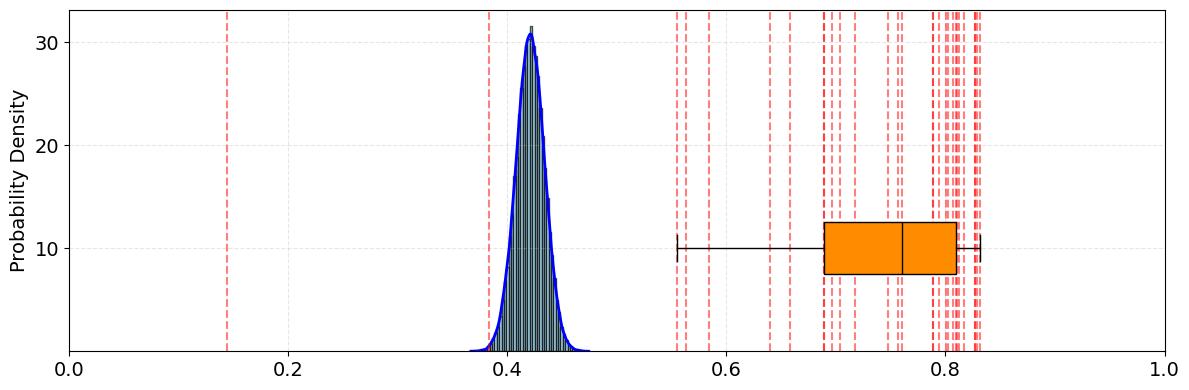

In [99]:
fig, ax1 = plot_f1_distribution_vs_box(n_distribution, f1_scores)
# fig.savefig("f1_distribution_vs_boxplot.png", dpi=300)
path=r"C:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\liset_tk\figures\pngs"
fig.savefig(os.path.join(path, "f1_distribution_vs_boxplot.png"), dpi=300)

In [ ]:
import seaborn as sns
def plot_f1_distribution_with_overlay(n_distribution, f1_scores):
    # KS test
    ks_stat, p_value = ks_2samp(f1_scores, n_distribution)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Histogram and KDE of permutation distribution
    sns.histplot(n_distribution, bins=50, kde=True, color="skyblue", label="Permutation F1s", stat="density", ax=ax)

    # Plot each actual F1 score as a vertical dashed line
    for score in f1_scores:
        ax.axvline(score, color='red', linestyle='--', alpha=0.4)

    # Overlay boxplot of actual F1 scores
    # Using a twin axis with narrow height just for boxplot (trick to overlay it)
    box_ax = ax.inset_axes([0, -0.15, 1, 0.1])  # [x0, y0, width, height]
    sns.boxplot(data=f1_scores, orient="h", ax=box_ax, color="salmon")
    box_ax.set_yticks([])
    box_ax.set_xlabel("")  # Hide x-axis label
    box_ax.set_xticks([])  # Optional: hide ticks

    # Match x limits of both axes
    box_ax.set_xlim(ax.get_xlim())

    # Main title and labels
    ax.set_title("Permutation F1 Distribution vs Actual F1 Scores", fontsize=14)
    ax.set_xlabel("F1 Score", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.3)

    # # Annotate KS p-value
    # ax.text(0.98, 0.95, f"KS p-value: {p_value:.4f}", transform=ax.transAxes,
    #         ha='right', va='top', fontsize=12,
    #         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    print(f"KS Test p-value: {p_value:.4f}")
    plt.tight_layout()
    return fig, ax, box_ax

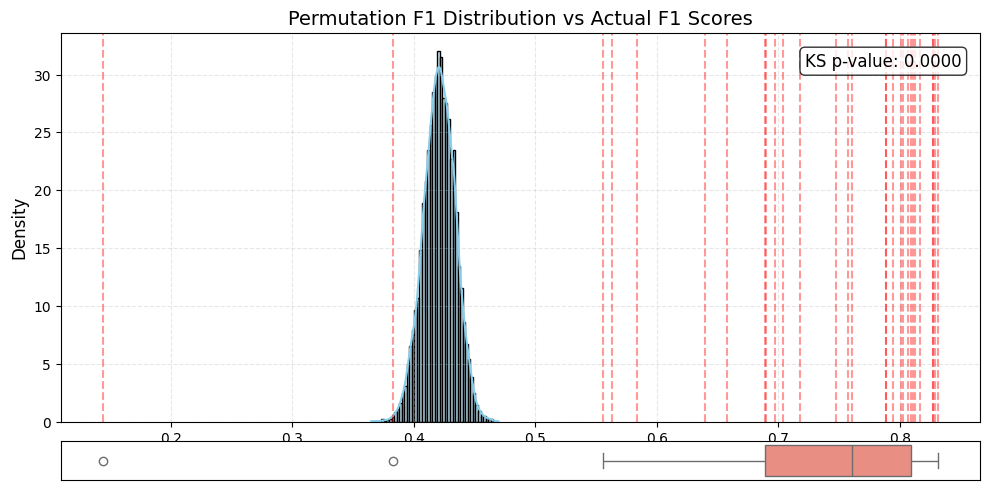

In [22]:
fig, ax, box_ax = plot_f1_distribution_with_overlay(n_distribution, f1_scores)